In [31]:
import yfinance as yf
from matplotlib import pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from statsmodels.tsa.stattools import adfuller

In [32]:
df_a = yf.download('MA', start = '2020-01-01', end = '2025-01-01')['Close']['MA']
df_b = yf.download('V', start = '2020-01-01', end = '2025-01-01')['Close']['V']


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


In [33]:
X = sm.add_constant(df_b)

model = sm.OLS(df_a, X).fit()
beta = model.params.iloc[1]

print("Hedge Ratio:", beta)




Hedge Ratio: 1.8277176988696808


In [34]:
spread = df_a - beta*df_b

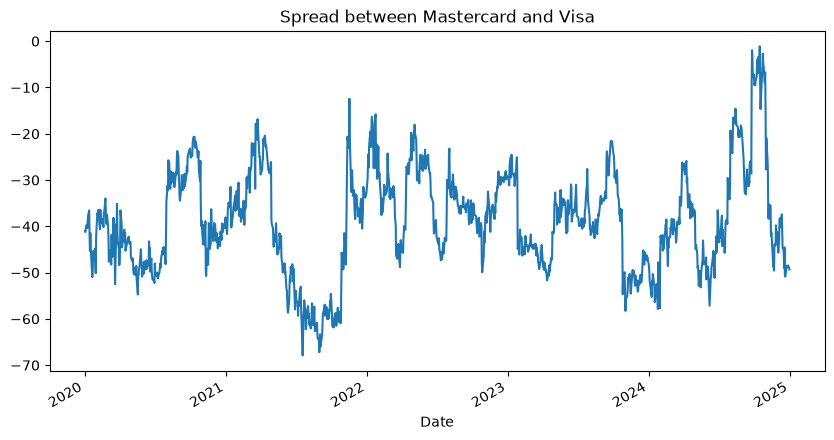

P-Value: 8.906602500370222e-05


In [35]:
spread.plot(figsize = (10,5), title = "Spread between Mastercard and Visa")
plt.show()

result = adfuller(spread)
print("P-Value:", result[1])